# Otay Mesa Industrial–Logistics Coupling — Canyu Li (standalone analysis)

**Research question.** Is industrial activity in the Otay Mesa border area more strongly
associated with ports of entry (POEs) and major freight corridors than industrial activity
in comparable non-border industrial areas of San Diego?

**What changed after the project meeting with Prof. Zaslavsky (and how this notebook responds):**

1. *Do Otay Mesa first; comparisons only as time allows.* → Otay Mesa is the primary case
   here; Kearny Mesa, Miramar and Sorrento Valley are non-border comparison areas computed
   with the **same** indicators.
2. *Industrial **zones** are a weak unit of analysis.* San Diego is spatially constrained
   ("city of villages" separated by canyons), so industrial **zoning may be "leftover" land**
   rather than a deliberate choice for freight access — and there are only ~5 industrial zones,
   too few for statistics. → The **unit of analysis is the census tract**, giving hundreds of
   observations and enabling real statistical comparison.
3. *Measure actual industrial activity, not just designations.* → Each tract carries
   **ACS industry-of-employment** counts (manufacturing + wholesale + transportation/warehousing),
   a free, reproducible measure of where industrial work actually is.
4. *Interpret as spatial association, explore both framings.* → We report proximity,
   overlap and relative concentration, run correlation/OLS, and keep causal language out.

**Why this notebook is standalone.** It reads only public sources (US Census TIGER + ACS API,
SANDAG FreightViewer with robust fallbacks) and uses **no ArcGIS license**. Teammates' outputs
(Joseph's Esri GeoEnrichment, Christian's geocoded business points) plug in through clearly
marked **optional hooks** that are OFF by default — the analysis runs fully without them.


In [15]:
"""
christian_data_prep_fixed.py
GPEC 447 — Otay Mesa Industrial-Logistics project
Fixed + hardened version of the business-tax -> geocoded-points pipeline.

WHAT THIS PRODUCES
  industrial_businesses_core_geocoded.csv   (freight-relevant core set)
  industrial_businesses_broad_geocoded.csv  (broad industrial ecosystem)

Each row has TRUE WGS84 longitude/latitude, ready for the notebook's Hook B.

KEY FIX IN THIS VERSION
  This script uses the same ArcGIS login logic that worked in Joseph's code:

      GIS(username=username)

  It does not use GIS("home"). It also does not pass gis=gis into batch_geocode(),
  because this DataHub ArcGIS API version does not accept that keyword argument.
  Instead, the signed-in GIS is set as arcgis.env.active_gis.
"""

from __future__ import annotations

import os
from pathlib import Path

import pandas as pd
import arcgis
from arcgis.gis import GIS
from arcgis.geocoding import batch_geocode

# Shared classification rule.
# Make sure industrial_classification.py is in the same folder.
from industrial_classification import add_classification


# ---------------------------------------------------------------------------
# Config
# ---------------------------------------------------------------------------

INPUT_FILES = [Path("tr_active1.csv"), Path("tr_active2.csv")]

MIN_SCORE = 85
OUT_SR = 4326

CORE_OUTPUT = "industrial_businesses_core_geocoded.csv"
BROAD_OUTPUT = "industrial_businesses_broad_geocoded.csv"

KEEP_CITIES = {
    "san diego",
    "chula vista",
    "national city",
    "imperial beach",
    "otay mesa",
    "san ysidro",
}

KEEP_ZIP_PREFIXES = ("919", "920", "921")


# ---------------------------------------------------------------------------
# ArcGIS connection — Joseph-style login
# ---------------------------------------------------------------------------

def connect_gis() -> GIS:
    """
    Connect to ArcGIS using the same logic that worked in Joseph's script:

        GIS(username=username)

    The username is read from ARCGIS_USERNAME if available. Otherwise, the
    script asks for it interactively.

    This function also sets arcgis.env.active_gis, so batch_geocode() can use
    the signed-in account without needing a gis= argument.
    """
    username = os.getenv("ARCGIS_USERNAME", "").strip()

    if not username:
        username = input("ArcGIS username: ").strip()

    if not username:
        raise RuntimeError("No ArcGIS username was provided.")

    gis = GIS(username=username)

    try:
        signed_in_user = gis.properties.user.username
    except Exception:
        try:
            signed_in_user = gis.users.me.username
        except Exception as exc:
            raise RuntimeError(
                "ArcGIS login was attempted, but no signed-in user could be verified."
            ) from exc

    arcgis.env.active_gis = gis

    print("Signed in as:", signed_in_user)
    return gis


# ---------------------------------------------------------------------------
# Column resolution
# ---------------------------------------------------------------------------

def _norm(c: str) -> str:
    """
    Normalize column names for fuzzy matching.
    """
    return (
        str(c)
        .strip()
        .lower()
        .replace(" ", "_")
        .replace("#", "num")
        .replace("-", "_")
    )


def resolve_columns(df: pd.DataFrame) -> pd.DataFrame:
    """
    Normalize headers and make sure the columns we rely on exist.
    """
    df = df.copy()
    df.columns = [_norm(c) for c in df.columns]

    wanted = {
        "business_acctnum": [
            "business_acctnum",
            "account_num",
            "acctnum",
            "account_number",
            "account_id",
        ],
        "dba_name": [
            "dba_name",
            "business_name",
            "dba",
            "name",
        ],
        "ownership_type": [
            "ownership_type",
            "ownership",
        ],
        "naics": [
            "naics",
            "naics_code",
            "naics_codes",
        ],
        "activity_desc": [
            "activity_desc",
            "naics_desc",
            "description",
            "business_activity",
        ],
        "address": [
            "address",
            "address_line_1",
            "street_address",
            "addr",
        ],
        "city": [
            "city",
            "business_city",
        ],
        "state": [
            "state",
            "business_state",
            "st",
        ],
        "zip": [
            "zip",
            "zip_code",
            "zipcode",
            "postal_code",
        ],
    }

    for canon, aliases in wanted.items():
        hit = next((a for a in aliases if a in df.columns), None)

        if hit and hit != canon:
            df = df.rename(columns={hit: canon})
        elif hit is None:
            df[canon] = ""

    return df


# ---------------------------------------------------------------------------
# Load -> clean -> classify -> filter
# ---------------------------------------------------------------------------

def load_business_tax() -> pd.DataFrame:
    """
    Load and deduplicate the San Diego business-tax files.
    """
    frames = []

    for file in INPUT_FILES:
        if file.exists():
            print(f"Reading {file}")
            frame = pd.read_csv(
                file,
                dtype=str,
                engine="python",
                on_bad_lines="skip",
            )
            frames.append(frame)
        else:
            print(f"WARNING: missing input file: {file}")

    if not frames:
        raise FileNotFoundError(f"None of the input files were found: {INPUT_FILES}")

    df = pd.concat(frames, ignore_index=True)
    df = resolve_columns(df)

    before = len(df)

    if df["business_acctnum"].replace("", pd.NA).notna().any():
        df = df.drop_duplicates(subset="business_acctnum")
    else:
        df = df.drop_duplicates()

    print(f"Rows: {before:,} -> {len(df):,} after deduplication")

    df = add_classification(df, naics_col="naics")

    return df


def in_study_region(df: pd.DataFrame) -> pd.Series:
    """
    Boolean mask: row is in or near the San Diego study region.
    """
    city_ok = (
        df["city"]
        .fillna("")
        .str.strip()
        .str.lower()
        .isin(KEEP_CITIES)
    )

    zip_ok = (
        df["zip"]
        .fillna("")
        .astype(str)
        .str.strip()
        .str.startswith(KEEP_ZIP_PREFIXES)
    )

    return city_ok | zip_ok


# ---------------------------------------------------------------------------
# Geocode
# ---------------------------------------------------------------------------

def _get_geo_column(df: pd.DataFrame, candidates: list[str]) -> str | None:
    """
    Find a geocoding result column using case-insensitive matching.
    """
    lower_map = {str(c).lower(): c for c in df.columns}

    for candidate in candidates:
        hit = lower_map.get(candidate.lower())
        if hit is not None:
            return hit

    return None


def geocode_and_export(
    df: pd.DataFrame,
    output_file: str,
) -> pd.DataFrame:
    """
    Geocode a filtered business DataFrame and export valid WGS84 lon/lat points.

    Important:
      batch_geocode() does not receive gis=gis in this DataHub environment.
      It uses arcgis.env.active_gis, which is set in connect_gis().
    """
    df = df.copy()

    df["full_address"] = (
        df["address"].fillna("") + ", "
        + df["city"].fillna("") + ", "
        + df["state"].fillna("") + " "
        + df["zip"].fillna("")
    )

    df["full_address"] = (
        df["full_address"]
        .str.replace(r"\s+", " ", regex=True)
        .str.strip(" ,")
    )

    df = df[df["full_address"].str.len() > 10].reset_index(drop=True)

    if df.empty:
        print(f"[skip] nothing to geocode for {output_file}")
        return df

    print(f"Geocoding {len(df):,} addresses for {output_file}")

    results = batch_geocode(
        df["full_address"].tolist(),
        out_sr=OUT_SR,
        as_featureset=True,
    )

    geo = results.sdf.reset_index(drop=True)

    x_col = _get_geo_column(geo, ["X", "x"])
    y_col = _get_geo_column(geo, ["Y", "y"])
    score_col = _get_geo_column(geo, ["Score", "score"])
    match_col = _get_geo_column(geo, ["Match_addr", "match_addr", "match_address"])
    status_col = _get_geo_column(geo, ["Status", "status"])

    missing_geo_cols = [
        name
        for name, col in {
            "X": x_col,
            "Y": y_col,
            "Score": score_col,
            "Match_addr": match_col,
            "Status": status_col,
        }.items()
        if col is None
    ]

    if missing_geo_cols:
        print("\nReturned geocoding columns:")
        print(geo.columns.tolist())
        raise RuntimeError(
            "Missing expected geocoding result columns: "
            + ", ".join(missing_geo_cols)
        )

    if len(geo) != len(df):
        raise RuntimeError(
            f"Geocoder returned {len(geo)} rows for {len(df)} input addresses. "
            "The script stopped to avoid misaligning addresses and coordinates."
        )

    df["longitude"] = pd.to_numeric(geo[x_col], errors="coerce")
    df["latitude"] = pd.to_numeric(geo[y_col], errors="coerce")
    df["geocode_score"] = pd.to_numeric(geo[score_col], errors="coerce")
    df["matched_address"] = geo[match_col]
    df["geocode_status"] = geo[status_col]

    keep = (
        (df["geocode_status"] == "M")
        & (df["geocode_score"] >= MIN_SCORE)
        & df["longitude"].between(-118.5, -116.0)
        & df["latitude"].between(32.3, 33.5)
    )

    before_quality_filter = len(df)
    df = df[keep].copy()

    print(
        f"Kept {len(df):,} of {before_quality_filter:,} geocoded rows "
        f"after status, score, and coordinate filters."
    )

    out_cols = [
        "business_acctnum",
        "dba_name",
        "ownership_type",
        "address",
        "city",
        "state",
        "zip",
        "naics",
        "activity_desc",
        "industry_group",
        "is_broad",
        "is_core",
        "full_address",
        "matched_address",
        "geocode_score",
        "longitude",
        "latitude",
    ]

    df = df[[c for c in out_cols if c in df.columns]].copy()
    df.to_csv(output_file, index=False)

    print(f"Exported {output_file}: {len(df):,} rows")

    if "industry_group" in df.columns and len(df) > 0:
        print(df["industry_group"].value_counts().to_string())

    return df


# ---------------------------------------------------------------------------
# Main
# ---------------------------------------------------------------------------

def main() -> None:
    connect_gis()

    biz = load_business_tax()

    biz = biz[in_study_region(biz)].copy()
    print(f"In study region: {len(biz):,}")

    core = biz[biz["is_core"]].copy()
    broad = biz[biz["is_broad"]].copy()

    print(f"Core: {len(core):,} | Broad: {len(broad):,}")

    geocode_and_export(core, CORE_OUTPUT)
    geocode_and_export(broad, BROAD_OUTPUT)


if __name__ == "__main__":
    main()

ArcGIS username:  gpec447sp26_14
Enter password:  ········


Signed in as: gpec447sp26_14
Reading tr_active1.csv
Reading tr_active2.csv
Rows: 51,921 -> 51,918 after deduplication
In study region: 49,343
Core: 3,357 | Broad: 4,721
Geocoding 3,357 addresses for industrial_businesses_core_geocoded.csv
Kept 3,342 of 3,357 geocoded rows after status, score, and coordinate filters.
Exported industrial_businesses_core_geocoded.csv: 3,342 rows
industry_group
Wholesale Trade                   1311
Manufacturing                     1117
Transportation and Warehousing     888
Industrial Machinery Repair         26
Geocoding 4,721 addresses for industrial_businesses_broad_geocoded.csv
Kept 4,701 of 4,721 geocoded rows after status, score, and coordinate filters.
Exported industrial_businesses_broad_geocoded.csv: 4,701 rows
industry_group
Transportation and Warehousing    2144
Wholesale Trade                   1412
Manufacturing                     1119
Industrial Machinery Repair         26


In [16]:
"""
joseph_enrich_to_tracts.py
GPEC 447 — Otay Mesa Industrial-Logistics project
Re-targeted GeoEnrichment step: San Diego County census tracts.

This script enriches San Diego County census tracts with Joseph's recommended
business and employee variables, then saves a tract-level CSV keyed by GEOID.

IMPORTANT:
  Keep TEST_MODE = True for the first run. This only enriches 3 tracts and saves
  esri_enrichment_by_tract_TEST.csv.

  After confirming that the output has enrichment columns, change TEST_MODE to
  False and run the full San Diego County tract enrichment.
"""

from __future__ import annotations

import re
from pathlib import Path

import pandas as pd
import geopandas as gpd

from arcgis.gis import GIS
from arcgis.features import GeoAccessor  # noqa: F401; enables pd.DataFrame.spatial
from arcgis.geoenrichment import enrich


# ---------------------------------------------------------------------------
# Configuration
# ---------------------------------------------------------------------------

GIS_USERNAME = "gpec447sp26_14"

# Keep True for first test run. Change to False only after the test output works.
TEST_MODE = True
TEST_N_TRACTS = 3

BATCH_SIZE = 150

OUTPUT_CSV = Path(
    "esri_enrichment_by_tract_TEST.csv" if TEST_MODE
    else "esri_enrichment_by_tract.csv"
)

TRACT_URL = (
    "https://www2.census.gov/geo/tiger/GENZ2023/shp/"
    "cb_2023_06_tract_500k.zip"
)


# ---------------------------------------------------------------------------
# Joseph's recommended variables — unchanged
# ---------------------------------------------------------------------------

ANALYSIS_VARIABLES = [
    # business counts
    "businesses.N06_BUS",   # Manufacturing 31-33
    "businesses.N07_BUS",   # Wholesale 42
    "businesses.N21_BUS",   # Transport/Warehouse 48-49
    "businesses.N21A_BUS",  # Truck transportation 484

    # employee counts
    "employees.N06_EMP",
    "employees.N07_EMP",
    "employees.N21_EMP",
    "employees.N21A_EMP",
]


# Friendly output names.
# These keys are the short ArcGIS variable codes that may appear either alone
# or as suffixes in returned column names, such as businesses.N06_BUS.
RENAME = {
    "N06_BUS": "esri_mfg_bus",
    "N07_BUS": "esri_whole_bus",
    "N21_BUS": "esri_trans_bus",
    "N21A_BUS": "esri_truck_bus",
    "N06_EMP": "esri_mfg_emp",
    "N07_EMP": "esri_whole_emp",
    "N21_EMP": "esri_trans_emp",
    "N21A_EMP": "esri_truck_emp",
}


# ---------------------------------------------------------------------------
# Helper functions
# ---------------------------------------------------------------------------

def normalize_colname(col: str) -> str:
    """
    Convert a returned ArcGIS column name into a simple comparable form.

    Examples:
      'businesses.N06_BUS' -> 'businesses_n06_bus'
      'N06_BUS'            -> 'n06_bus'
      'n06_bus'            -> 'n06_bus'
    """
    return re.sub(r"[^a-z0-9]+", "_", str(col).lower()).strip("_")


def find_geoid_column(columns: list[str]) -> str | None:
    """
    Find the GEOID column, allowing for minor capitalization differences.
    """
    for col in columns:
        if normalize_colname(col) == "geoid":
            return col
    return None


def find_enrichment_columns(columns: list[str]) -> dict[str, str]:
    """
    Match ArcGIS returned columns to the expected enrichment variables.

    Returns:
      dict where keys are friendly output names and values are source columns.
    """
    matched = {}

    for short_code, friendly_name in RENAME.items():
        short_norm = normalize_colname(short_code)

        possible_matches = []
        for col in columns:
            col_norm = normalize_colname(col)

            if col_norm == short_norm or col_norm.endswith("_" + short_norm):
                possible_matches.append(col)

        if possible_matches:
            # Prefer the shortest / cleanest match if multiple variants exist.
            possible_matches = sorted(possible_matches, key=lambda x: len(str(x)))
            matched[friendly_name] = possible_matches[0]

    return matched


def load_sd_tracts() -> gpd.GeoDataFrame:
    """
    Load San Diego County census tracts from Census TIGER/GENZ 2023.

    GeoEnrichment expects geographic coordinates, so output CRS is EPSG:4326.
    """
    ca_tracts = gpd.read_file(TRACT_URL)

    sd_tracts = ca_tracts[ca_tracts["COUNTYFP"] == "073"].copy()
    sd_tracts["GEOID"] = sd_tracts["GEOID"].astype(str)

    sd_tracts = sd_tracts[["GEOID", "geometry"]].copy()
    sd_tracts = sd_tracts[sd_tracts.geometry.notna()].copy()
    sd_tracts = sd_tracts[~sd_tracts.geometry.is_empty].copy()

    return sd_tracts.to_crs("EPSG:4326")


def clean_enrichment_output(raw: pd.DataFrame) -> pd.DataFrame:
    """
    Convert raw GeoEnrichment output into a clean tract-level DataFrame.

    This function prevents the earlier problem where all enrichment columns were
    dropped because their returned names did not exactly match RENAME keys.
    """
    print("\nReturned columns from GeoEnrichment:")
    for col in raw.columns:
        print(f"  {repr(col)}")

    geoid_col = find_geoid_column(list(raw.columns))
    if geoid_col is None:
        raise RuntimeError(
            "No GEOID column was found in the GeoEnrichment output. "
            "Check whether input tract attributes were preserved."
        )

    matched_cols = find_enrichment_columns(list(raw.columns))

    print("\nMatched enrichment columns:")
    if matched_cols:
        for friendly_name, source_col in matched_cols.items():
            print(f"  {source_col!r} -> {friendly_name!r}")
    else:
        print("  None")

    if not matched_cols:
        raise RuntimeError(
            "GeoEnrichment completed, but none of the expected enrichment "
            "variable columns were found. The script will not save a GEOID-only CSV."
        )

    clean = pd.DataFrame()
    clean["GEOID"] = raw[geoid_col].astype(str)

    for friendly_name, source_col in matched_cols.items():
        clean[friendly_name] = pd.to_numeric(raw[source_col], errors="coerce")

    expected_friendly_names = list(RENAME.values())
    missing = [name for name in expected_friendly_names if name not in clean.columns]

    if missing:
        print("\nWARNING: These expected enrichment variables were not found:")
        for name in missing:
            print(f"  {name}")

    # Convenience aggregates matching the project notebook's industrial definition.
    bus_cols = [
        c for c in ["esri_mfg_bus", "esri_whole_bus", "esri_trans_bus"]
        if c in clean.columns
    ]
    emp_cols = [
        c for c in ["esri_mfg_emp", "esri_whole_emp", "esri_trans_emp"]
        if c in clean.columns
    ]

    if bus_cols:
        clean["esri_industrial_bus"] = clean[bus_cols].sum(axis=1, skipna=True)

    if emp_cols:
        clean["esri_industrial_emp"] = clean[emp_cols].sum(axis=1, skipna=True)

    print("\nFinal output columns:")
    for col in clean.columns:
        print(f"  {col}")

    return clean


def enrich_tracts(
    gis: GIS,
    tracts: gpd.GeoDataFrame,
    batch_size: int = BATCH_SIZE
) -> pd.DataFrame:
    """
    Enrich tract polygons in batches.

    Returns:
      clean DataFrame keyed by GEOID.
    """
    frames = []

    for start in range(0, len(tracts), batch_size):
        end = min(start + batch_size, len(tracts))
        chunk = tracts.iloc[start:end].copy().reset_index(drop=True)

        # ArcGIS accepts a spatially enabled DataFrame as study_areas.
        chunk_sdf = pd.DataFrame.spatial.from_geodataframe(chunk.to_crs("EPSG:4326"))

        result = enrich(
            study_areas=chunk_sdf,
            analysis_variables=ANALYSIS_VARIABLES,
            gis=gis
        )

        result = pd.DataFrame(result)

        # Drop geometry column if present.
        result = result.drop(columns=["SHAPE", "Shape", "geometry"], errors="ignore")

        # Preserve GEOID if ArcGIS did not return it.
        if find_geoid_column(list(result.columns)) is None:
            if len(result) != len(chunk):
                raise RuntimeError(
                    f"Batch {start}-{end - 1}: GeoEnrichment returned {len(result)} "
                    f"rows for {len(chunk)} input tracts, so GEOID cannot be safely attached."
                )
            result["GEOID"] = chunk["GEOID"].values

        frames.append(result)

        print(f"  enriched tracts {start}-{end - 1}")

    raw = pd.concat(frames, ignore_index=True)
    clean = clean_enrichment_output(raw)

    return clean


# ---------------------------------------------------------------------------
# Main
# ---------------------------------------------------------------------------

def main() -> None:
    gis = GIS(username=GIS_USERNAME)
    print("Signed in as:", gis.properties.user.username)

    tracts = load_sd_tracts()
    print(f"San Diego County tracts loaded: {len(tracts):,}")

    if TEST_MODE:
        tracts = tracts.head(TEST_N_TRACTS).copy()
        print(f"TEST_MODE is ON: enriching only {len(tracts):,} tracts.")
    else:
        print("TEST_MODE is OFF: enriching all San Diego County tracts.")

    enriched = enrich_tracts(gis, tracts, batch_size=BATCH_SIZE)

    # Safety check: do not save a useless GEOID-only CSV.
    if enriched.shape[1] <= 1:
        raise RuntimeError(
            "Output has only GEOID. The CSV was not saved because enrichment "
            "variables are missing."
        )

    enriched.to_csv(OUTPUT_CSV, index=False)

    print(
        f"\nSaved {OUTPUT_CSV}: "
        f"{len(enriched):,} rows, {enriched.shape[1]} columns"
    )

    print("\nPreview:")
    print(enriched.head().to_string(index=False))


if __name__ == "__main__":
    main()

Enter password:  ········


Signed in as: gpec447sp26_14
San Diego County tracts loaded: 736
TEST_MODE is ON: enriching only 3 tracts.
  enriched tracts 0-2

Returned columns from GeoEnrichment:
  'source_country'
  'aggregation_method'
  'population_to_polygon_size_rating'
  'apportionment_confidence'
  'has_data'
  'n06_bus'
  'n07_bus'
  'n21_bus'
  'n21a_bus'
  'n06_emp'
  'n07_emp'
  'n21_emp'
  'n21a_emp'
  'GEOID'

Matched enrichment columns:
  'n06_bus' -> 'esri_mfg_bus'
  'n07_bus' -> 'esri_whole_bus'
  'n21_bus' -> 'esri_trans_bus'
  'n21a_bus' -> 'esri_truck_bus'
  'n06_emp' -> 'esri_mfg_emp'
  'n07_emp' -> 'esri_whole_emp'
  'n21_emp' -> 'esri_trans_emp'
  'n21a_emp' -> 'esri_truck_emp'

Final output columns:
  GEOID
  esri_mfg_bus
  esri_whole_bus
  esri_trans_bus
  esri_truck_bus
  esri_mfg_emp
  esri_whole_emp
  esri_trans_emp
  esri_truck_emp
  esri_industrial_bus
  esri_industrial_emp

Saved esri_enrichment_by_tract_TEST.csv: 3 rows, 11 columns

Preview:
      GEOID  esri_mfg_bus  esri_whole_bus 

## 1. Setup — packages, folders, CRS, and configuration

`EPSG:2230` (NAD83 / California zone 6, US survey feet) is the projected CRS for all
distance and area work, so 1 mile = 5280 feet exactly.

In [17]:
%matplotlib inline
from pathlib import Path
import warnings
import requests
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point

warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.max_columns", 120)

# Project folders
PROJECT_DIR    = Path.cwd()
DATA_PROCESSED = PROJECT_DIR / "data_processed"
FIGURES        = PROJECT_DIR / "figures"
TABLES         = PROJECT_DIR / "tables"
for d in (DATA_PROCESSED, FIGURES, TABLES):
    d.mkdir(parents=True, exist_ok=True)

TARGET_CRS  = "EPSG:2230"   # NAD83 / California zone 6 (US survey feet)
FT_PER_MILE = 5280.0
ACS_YEAR    = 2023

# --- OPTIONAL integration hooks (OFF -> this notebook is fully standalone) ---
# Turn ON only when the corresponding teammate output exists in data_processed/.
USE_ESRI_ENRICHMENT = False   # Joseph : data_processed/esri_enrichment_by_tract.csv
USE_BUSINESS_POINTS = False   # Christian: data_processed/industrial_businesses_core_geocoded.csv

print("Project dir :", PROJECT_DIR)
print("Target CRS  :", TARGET_CRS, "(US survey feet)")
print("ACS year    :", ACS_YEAR)
print("Hooks       : Esri =", USE_ESRI_ENRICHMENT, "| business points =", USE_BUSINESS_POINTS)

Project dir : /home/cal081/private/GPEC447_Group_Project
Target CRS  : EPSG:2230 (US survey feet)
ACS year    : 2023
Hooks       : Esri = False | business points = False


## 2. Helper functions

Small, reusable helpers following the homework pattern of checking each object after
it is created. `read_esri_or_geojson_url` matters because the SANDAG FreightViewer files
are **Esri FeatureSet JSON**, not GeoJSON.

In [18]:
def inspect_gdf(gdf, name="GeoDataFrame", n=3):
    # Quick diagnostics; run after loading any spatial layer.
    print(f"--- {name} ---")
    print("shape:", gdf.shape, "| crs:", gdf.crs)
    print("geometry types:", dict(gdf.geom_type.value_counts(dropna=False)))
    print("columns:", list(gdf.columns))
    display(gdf.head(n))

def to_target(gdf, assumed="EPSG:4326"):
    # Reproject to TARGET_CRS; set an assumed CRS first if missing.
    if gdf.crs is None:
        gdf = gdf.set_crs(assumed)
    return gdf.to_crs(TARGET_CRS)

def read_geojson_url(url, name, assumed="EPSG:4326"):
    gdf = gpd.read_file(url)
    gdf = to_target(gdf, assumed)
    print(f"[ok] {name}: {len(gdf):,} features")
    return gdf

def read_esri_or_geojson_url(url, name, assumed="EPSG:4326"):
    # SANDAG FreightViewer files are Esri FeatureSet JSON, not GeoJSON.
    # Try GeoPandas/GDAL first; if that yields nothing, parse the Esri JSON by hand.
    try:
        gdf = gpd.read_file(url)
        if len(gdf):
            print(f"[ok] {name}: {len(gdf):,} features (gdal)")
            return to_target(gdf, assumed)
    except Exception:
        pass
    from shapely.geometry import LineString, MultiLineString, Polygon, MultiPolygon
    js = requests.get(url, timeout=60).json()
    feats = js.get("features", [])
    sr = js.get("spatialReference", {}) or {}
    epsg = sr.get("latestWkid") or sr.get("wkid") or 4326
    geoms, rows = [], []
    for f in feats:
        g = f.get("geometry", {}) or {}
        attrs = f.get("attributes", {}) or {}
        geom = None
        if "x" in g and "y" in g:
            geom = Point(g["x"], g["y"])
        elif "paths" in g:
            lines = [LineString(p) for p in g["paths"] if len(p) > 1]
            geom = lines[0] if len(lines) == 1 else (MultiLineString(lines) if lines else None)
        elif "rings" in g:
            rings = [Polygon(r) for r in g["rings"] if len(r) > 2]
            geom = rings[0] if len(rings) == 1 else (MultiPolygon(rings) if rings else None)
        if geom is not None:
            geoms.append(geom); rows.append(attrs)
    gdf = gpd.GeoDataFrame(rows, geometry=geoms, crs=f"EPSG:{epsg}")
    print(f"[ok] {name}: {len(gdf):,} features (esri-json)")
    return to_target(gdf, assumed)

def linear_fit(x, y):
    # Closed-form OLS y = a + b*x with Pearson r and R^2 (numpy only, no extra deps).
    x = np.asarray(x, float); y = np.asarray(y, float)
    m = np.isfinite(x) & np.isfinite(y)
    x, y = x[m], y[m]
    if len(x) < 3:
        return {"n": int(len(x)), "slope": np.nan, "intercept": np.nan, "r": np.nan, "r2": np.nan}
    b, a = np.polyfit(x, y, 1)
    r = float(np.corrcoef(x, y)[0, 1])
    return {"n": int(len(x)), "slope": float(b), "intercept": float(a), "r": r, "r2": r**2}

## 3. Census tracts for San Diego County (the unit of analysis)

TIGER/Line cartographic-boundary tracts for California, subset to San Diego County
(`COUNTYFP == "073"`).

In [19]:
TRACT_URL = "https://www2.census.gov/geo/tiger/GENZ2023/shp/cb_2023_06_tract_500k.zip"
tracts_ca = gpd.read_file(TRACT_URL)
tracts_sd = tracts_ca[tracts_ca["COUNTYFP"] == "073"].copy().to_crs(TARGET_CRS)
tracts_sd["GEOID"] = tracts_sd["GEOID"].astype(str)
tracts_sd["area_sqmi"] = tracts_sd.geometry.area / (FT_PER_MILE ** 2)
inspect_gdf(tracts_sd, "San Diego County census tracts (2023)")

--- San Diego County census tracts (2023) ---
shape: (736, 15) | crs: EPSG:2230
geometry types: {'Polygon': 735, 'MultiPolygon': 1}
columns: ['STATEFP', 'COUNTYFP', 'TRACTCE', 'GEOIDFQ', 'GEOID', 'NAME', 'NAMELSAD', 'STUSPS', 'NAMELSADCO', 'STATE_NAME', 'LSAD', 'ALAND', 'AWATER', 'geometry', 'area_sqmi']


,STATEFP,COUNTYFP,TRACTCE,GEOIDFQ,GEOID,NAME,NAMELSAD,STUSPS,NAMELSADCO,STATE_NAME,LSAD,ALAND,AWATER,geometry,area_sqmi
131,06,073,003212,1400000US06073003212,06073003212,32.12,Census Tract 32.12,CA,San Diego County,California,CT,1257736,0,"POLYGON ((6311880.924 1822303.944, 6312259.685...",0.491883
132,06,073,013104,1400000US06073013104,06073013104,131.04,Census Tract 131.04,CA,San Diego County,California,CT,977893,0,"POLYGON ((6304832.054 1805358.979, 6306101.849...",0.377696
133,06,073,020902,1400000US06073020902,06073020902,209.02,Census Tract 209.02,CA,San Diego County,California,CT,422787620,7987272,"POLYGON ((6395854.291 1910128.055, 6396039.583...",166.233949


## 4. ACS industry-of-employment, by tract

The 2019–2023 ACS Data Profile (DP03) gives civilian employment by industry. The
**industrial-logistics proxy** is manufacturing + wholesale + transportation/warehousing,
which lines up with NAICS 31–33 / 42 / 48–49 — the same definition the rest of the team uses.

> **Fixed:** the universe (denominator) is `DP03_0032E` (*civilian employed population 16+*).
> An earlier draft used `DP03_0033E`, which is *agriculture/forestry/fishing/mining* — that
> made `industrial_share` wrong. Corrected below.

In [22]:
# 4. ACS industry-of-employment by tract
# Pull ACS Data Profile industry employment variables for San Diego County tracts.

import os
import getpass
import requests
import pandas as pd
import numpy as np

ACS_YEAR = 2023

# Read Census API key from environment, or ask once at runtime.
CENSUS_API_KEY = os.getenv("CENSUS_API_KEY", "").strip()

if not CENSUS_API_KEY:
    CENSUS_API_KEY = getpass.getpass("Enter Census API key: ").strip()
    os.environ["CENSUS_API_KEY"] = CENSUS_API_KEY

if not CENSUS_API_KEY:
    raise RuntimeError("A Census API key is required for this request.")

# DP03 Data Profile variables
# DP03_0032E Civilian employed population 16+  (UNIVERSE / denominator)
# DP03_0034E Construction                     (NAICS 23; reported but not core proxy)
# DP03_0035E Manufacturing                    (NAICS 31-33)
# DP03_0036E Wholesale trade                  (NAICS 42)
# DP03_0038E Transportation & warehousing, and utilities (NAICS 48-49 + 22)

acs_vars = [
    "NAME",
    "DP03_0032E",
    "DP03_0034E",
    "DP03_0035E",
    "DP03_0036E",
    "DP03_0038E",
]

base = f"https://api.census.gov/data/{ACS_YEAR}/acs/acs5/profile"

params = {
    "get": ",".join(acs_vars),
    "for": "tract:*",
    "in": "state:06 county:073",
    "key": CENSUS_API_KEY,
}

resp = requests.get(base, params=params, timeout=60)

print("ACS request URL:")
safe_url = resp.url.replace(CENSUS_API_KEY, "CENSUS_API_KEY_HIDDEN")
print(safe_url)
print("Status code:", resp.status_code)
print("Content-Type:", resp.headers.get("Content-Type"))

text_preview = resp.text[:1000]

if resp.status_code != 200:
    raise RuntimeError(
        f"Census API request failed with status {resp.status_code}.\n\n"
        f"Response preview:\n{text_preview}"
    )

if not resp.text.strip().startswith("["):
    raise RuntimeError(
        "Census API did not return JSON array data.\n\n"
        f"Response preview:\n{text_preview}"
    )

rows = resp.json()

if len(rows) <= 1:
    raise RuntimeError(
        "Census API returned no tract-level data.\n\n"
        f"Response preview:\n{text_preview}"
    )

acs = pd.DataFrame(rows[1:], columns=rows[0])

# Construct tract GEOID: state + county + tract
acs["GEOID"] = acs["state"] + acs["county"] + acs["tract"]

rename = {
    "DP03_0032E": "emp_total",
    "DP03_0034E": "emp_construction",
    "DP03_0035E": "emp_manufacturing",
    "DP03_0036E": "emp_wholesale",
    "DP03_0038E": "emp_transport_wh_util",
}

acs = acs.rename(columns=rename)

for c in rename.values():
    acs[c] = pd.to_numeric(acs[c], errors="coerce")

# Shared industrial-logistics definition:
# manufacturing + wholesale + transportation/warehousing/utilities
acs["industrial_emp"] = (
    acs["emp_manufacturing"].fillna(0)
    + acs["emp_wholesale"].fillna(0)
    + acs["emp_transport_wh_util"].fillna(0)
)

acs["industrial_share"] = (
    acs["industrial_emp"] / acs["emp_total"].replace(0, np.nan)
)

keep = [
    "GEOID",
    "NAME",
    "emp_total",
    "emp_construction",
    "emp_manufacturing",
    "emp_wholesale",
    "emp_transport_wh_util",
    "industrial_emp",
    "industrial_share",
]

acs = acs[keep].copy()

print("ACS tracts:", acs.shape)

display(acs.head())

Enter Census API key:  ········


ACS request URL:
https://api.census.gov/data/2023/acs/acs5/profile?get=NAME%2CDP03_0032E%2CDP03_0034E%2CDP03_0035E%2CDP03_0036E%2CDP03_0038E&for=tract%3A%2A&in=state%3A06+county%3A073&key=CENSUS_API_KEY_HIDDEN
Status code: 200
Content-Type: application/json;charset=utf-8
ACS tracts: (737, 9)


,GEOID,NAME,emp_total,emp_construction,emp_manufacturing,emp_wholesale,emp_transport_wh_util,industrial_emp,industrial_share
0,06073000100,Census Tract 1; San Diego County; California,1191,26,113,46,16,175,0.146935
1,06073000201,Census Tract 2.01; San Diego County; California,1100,19,105,0,34,139,0.126364
2,06073000202,Census Tract 2.02; San Diego County; California,2610,122,285,59,19,363,0.139080
3,06073000301,Census Tract 3.01; San Diego County; California,1494,0,98,12,111,221,0.147925
4,06073000302,Census Tract 3.02; San Diego County; California,1899,28,31,0,25,56,0.029489


## 5. Join ACS to the tract geometries

In [23]:
keep = ["GEOID","NAME","emp_total","emp_construction","emp_manufacturing",
        "emp_wholesale","emp_transport_wh_util","industrial_emp","industrial_share"]
tracts = tracts_sd.merge(acs[keep], on="GEOID", how="left")
tracts["industrial_emp_density"] = tracts["industrial_emp"] / tracts["area_sqmi"]
print("Tracts with ACS:", tracts.shape,
      "| missing industrial_emp:", int(tracts["industrial_emp"].isna().sum()))
display(tracts.drop(columns="geometry").head())

Tracts with ACS: (736, 24) | missing industrial_emp: 0


,STATEFP,COUNTYFP,TRACTCE,GEOIDFQ,GEOID,NAME_x,NAMELSAD,STUSPS,NAMELSADCO,STATE_NAME,LSAD,ALAND,AWATER,area_sqmi,NAME_y,emp_total,emp_construction,emp_manufacturing,emp_wholesale,emp_transport_wh_util,industrial_emp,industrial_share,industrial_emp_density
0,06,073,003212,1400000US06073003212,06073003212,32.12,Census Tract 32.12,CA,San Diego County,California,CT,1257736,0,0.491883,Census Tract 32.12; San Diego County; California,1855,171,75,0,120,195,0.105121,396.435874
1,06,073,013104,1400000US06073013104,06073013104,131.04,Census Tract 131.04,CA,San Diego County,California,CT,977893,0,0.377696,Census Tract 131.04; San Diego County; California,2762,237,183,71,212,466,0.168718,1233.795994
2,06,073,020902,1400000US06073020902,06073020902,209.02,Census Tract 209.02,CA,San Diego County,California,CT,422787620,7987272,166.233949,Census Tract 209.02; San Diego County; California,697,32,39,0,95,134,0.192253,0.806093
3,06,073,015902,1400000US06073015902,06073015902,159.02,Census Tract 159.02,CA,San Diego County,California,CT,1106949,0,0.428740,Census Tract 159.02; San Diego County; California,2221,399,68,49,82,199,0.089599,464.150857
4,06,073,004501,1400000US06073004501,06073004501,45.01,Census Tract 45.01,CA,San Diego County,California,CT,327790,0,0.126787,Census Tract 45.01; San Diego County; California,2254,104,71,61,76,208,0.092280,1640.552553


## 6. Freight infrastructure — ports of entry and major corridors

Loaded from SANDAG FreightViewer, with **fallbacks that keep the analysis runnable** even if
SANDAG is unreachable:
* POEs → fall back to the two canonical San Diego POEs (San Ysidro, Otay Mesa).
* Major roads → fall back to Census TIGER primary/secondary roads for San Diego County.

In [24]:
# ---- Ports of entry (with built-in fallback) -------------------------------
POE_FALLBACK = gpd.GeoDataFrame(
    {"name": ["San Ysidro POE", "Otay Mesa POE"]},
    geometry=[Point(-117.0299, 32.5421), Point(-116.9385, 32.5527)],
    crs="EPSG:4326",
).to_crs(TARGET_CRS)   # approximate coordinates; used only if SANDAG layer fails

try:
    poe = read_esri_or_geojson_url(
        "https://gis.sandag.org/FreightViewer/data/poe_points_update.json",
        "SANDAG POE points")
    if poe is None or len(poe) == 0:
        raise ValueError("empty POE layer")
    poe_source = "SANDAG FreightViewer"
except Exception as e:
    print("[fallback] SANDAG POE unavailable -> built-in POE coordinates:", e)
    poe = POE_FALLBACK.copy()
    poe_source = "built-in fallback (approximate)"
print("POE source:", poe_source, "| n =", len(poe))

# ---- Major roads / freight corridors (with Census fallback) ----------------
roads, roads_source = None, None
try:
    roads = read_esri_or_geojson_url(
        "https://gis.sandag.org/FreightViewer/data/MajorRoads_20171002.json",
        "SANDAG major roads")
    if roads is not None and len(roads):
        roads_source = "SANDAG FreightViewer major roads"
except Exception as e:
    print("[fallback] SANDAG roads unavailable:", e)

if roads is None or len(roads) == 0:
    try:
        roads = gpd.read_file(
            "https://www2.census.gov/geo/tiger/TIGER2023/PRISECROADS/tl_2023_06073_prisecroads.zip")
        roads = to_target(roads)
        if "MTFCC" in roads.columns:   # S1100 primary (interstates/US hwys), S1200 secondary
            roads = roads[roads["MTFCC"].isin(["S1100", "S1200"])].copy()
        roads_source = "Census TIGER primary/secondary roads (fallback)"
    except Exception as e:
        print("[warn] no road layer; corridor indicators will be skipped:", e)

print("Roads source:", roads_source, "| n =", 0 if roads is None else len(roads))

[ok] SANDAG POE points: 10 features (gdal)
POE source: SANDAG FreightViewer | n = 10
[ok] SANDAG major roads: 45 features (gdal)
Roads source: SANDAG FreightViewer major roads | n = 45


## 7. Study areas — Otay Mesa (border) vs. non-border comparisons

Each area is a circular selection window around a known center. A tract is assigned to an
area when its representative point falls inside that window. Otay Mesa is the border case;
the other three are non-border industrial comparisons.

In [25]:
AREA_CENTERS = {
    "Otay Mesa":       (-117.0548, 32.5751),   # border
    "Kearny Mesa":     (-117.1397, 32.8264),   # non-border comparison
    "Miramar":         (-117.1050, 32.8970),   # non-border comparison
    "Sorrento Valley": (-117.2025, 32.8948),   # non-border comparison
}
AREA_RADIUS_MI = 3.0
BORDER_AREAS = ["Otay Mesa"]

area_windows = {}
for name, (lon, lat) in AREA_CENTERS.items():
    c = gpd.GeoDataFrame(geometry=[Point(lon, lat)], crs="EPSG:4326").to_crs(TARGET_CRS)
    area_windows[name] = c.geometry.iloc[0].buffer(AREA_RADIUS_MI * FT_PER_MILE)

tracts["area"] = "Other"
rep_pts = tracts.geometry.representative_point()
for name, win in area_windows.items():
    tracts.loc[rep_pts.within(win), "area"] = name

tracts["border"] = np.where(tracts["area"].isin(BORDER_AREAS), "Border (Otay Mesa)",
                    np.where(tracts["area"] == "Other", "Other", "Non-border comparison"))
print(tracts["area"].value_counts())

area
Other              647
Otay Mesa           32
Sorrento Valley     21
Kearny Mesa         18
Miramar             18
Name: count, dtype: int64


## 8. Proximity indicators for every tract

Three geometry-only indicators (no teammate data required):
1. `dist_poe_mi` — straight-line distance from the tract's representative point to the nearest POE.
2. `dist_road_mi` — distance to the nearest major freight road.
3. `share_within_1mi_corridor` — fraction of the tract's area within 1 mile of a major road.

In [26]:
rep = tracts.geometry.representative_point()

# Distance to nearest POE
poe_u = poe.union_all()
tracts["dist_poe_mi"] = rep.apply(lambda g: g.distance(poe_u)) / FT_PER_MILE

# Road-based indicators (only if a road layer is available)
if roads is not None and len(roads):
    roads_u = roads.union_all()
    tracts["dist_road_mi"] = rep.apply(lambda g: g.distance(roads_u)) / FT_PER_MILE

    buf1 = roads.buffer(1 * FT_PER_MILE).union_all()
    buf_gdf = gpd.GeoDataFrame({"b": [1]}, geometry=[buf1], crs=TARGET_CRS)
    tracts["tract_area"] = tracts.geometry.area
    ov = gpd.overlay(tracts[["GEOID", "geometry", "tract_area"]], buf_gdf, how="intersection")
    ov["ov_area"] = ov.geometry.area
    s = ov.groupby("GEOID", as_index=False)["ov_area"].sum()
    tracts = tracts.merge(s, on="GEOID", how="left")
    tracts["ov_area"] = tracts["ov_area"].fillna(0)
    tracts["share_within_1mi_corridor"] = tracts["ov_area"] / tracts["tract_area"]
else:
    tracts["dist_road_mi"] = np.nan
    tracts["share_within_1mi_corridor"] = np.nan

prev = ["GEOID","area","industrial_emp","industrial_emp_density",
        "dist_poe_mi","dist_road_mi","share_within_1mi_corridor"]
display(tracts[prev].head(8))

,GEOID,area,industrial_emp,industrial_emp_density,dist_poe_mi,dist_road_mi,share_within_1mi_corridor
0,06073003212,Other,195,396.435874,8.903965,0.351485,1.000000
1,06073013104,Otay Mesa,466,1233.795994,5.457119,0.756513,0.955570
2,06073020902,Other,134,0.806093,24.284568,3.576700,0.132891
3,06073015902,Other,199,464.150857,16.296353,0.510707,0.995909
4,06073004501,Other,208,1640.552553,13.484592,0.322914,1.000000
5,06073002002,Other,128,258.015199,15.647771,0.976987,0.738078
6,06073012302,Other,40,253.747117,7.366765,0.949760,0.625279
7,06073011601,Other,518,1828.159541,9.241785,0.780917,1.000000


## 9. Optional integration hooks (OFF by default)

These let the notebook *optionally* consume teammates' outputs without depending on them.
Leave the flags in Cell 1 OFF for a fully standalone run.

* **Hook A — Joseph (Esri GeoEnrichment).** Richer business/employee counts per tract.
  Expects `data_processed/esri_enrichment_by_tract.csv` with a `GEOID` column
  (produced by `joseph_enrich_to_tracts.py`).
* **Hook B — Christian (geocoded business points).** Validates the ACS picture with actual
  geocoded establishments. Expects `data_processed/industrial_businesses_core_geocoded.csv`
  with `longitude`/`latitude` in WGS84 (produced by `christian_data_prep_fixed.py`).

In [27]:
# Hook A — Joseph's Esri GeoEnrichment, by tract
if USE_ESRI_ENRICHMENT:
    p = DATA_PROCESSED / "esri_enrichment_by_tract.csv"
    enr = pd.read_csv(p, dtype={"GEOID": str})
    enr.columns = [c.strip() for c in enr.columns]
    new_cols = [c for c in enr.columns if c != "GEOID"]
    tracts = tracts.merge(enr, on="GEOID", how="left")
    print("[hook A] merged Esri enrichment columns:", new_cols)
else:
    print("[hook A] OFF — using ACS employment only (fully standalone).")

[hook A] OFF — using ACS employment only (fully standalone).


In [28]:
# Hook B — Christian's geocoded business points, counted per tract
if USE_BUSINESS_POINTS:
    p = DATA_PROCESSED / "industrial_businesses_core_geocoded.csv"
    bdf = pd.read_csv(p)
    bpts = gpd.GeoDataFrame(
        bdf, geometry=gpd.points_from_xy(bdf["longitude"], bdf["latitude"]),
        crs="EPSG:4326").to_crs(TARGET_CRS)
    joined = gpd.sjoin(bpts, tracts[["GEOID", "geometry"]], how="inner", predicate="within")
    cnt = joined.groupby("GEOID").size().rename("business_points").reset_index()
    tracts = tracts.merge(cnt, on="GEOID", how="left")
    tracts["business_points"] = tracts["business_points"].fillna(0)
    fit = linear_fit(tracts["business_points"], tracts["industrial_emp"])
    print(f"[hook B] geocoded points vs ACS industrial employment: r = {fit['r']:.2f} (n={fit['n']})")
else:
    print("[hook B] OFF — analysis does not require geocoded business points.")

[hook B] OFF — analysis does not require geocoded business points.


## 10. Main analysis table

One row per tract, all indicators. Saved to `tables/tract_indicators.csv`.

In [32]:
# 10. Main analysis table
# One row per tract, all indicators. Saved to tables/tract_indicators.csv.

from pathlib import Path

TABLES = Path("tables")
TABLES.mkdir(exist_ok=True)

# Use active geometry column name.
geom_col = tracts.geometry.name

# ------------------------------------------------------------
# Clean / standardize identifier columns
# ------------------------------------------------------------

# If ACS join created NAME_y or NAME_x, standardize it to NAME.
if "NAME" not in tracts.columns:
    if "NAME_y" in tracts.columns:
        tracts = tracts.rename(columns={"NAME_y": "NAME"})
    elif "NAME_x" in tracts.columns:
        tracts = tracts.rename(columns={"NAME_x": "NAME"})

# If an earlier version created 'a', standardize to 'area'.
# In the current notebook, the available column is 'area', so we use 'area'.
if "area" not in tracts.columns and "a" in tracts.columns:
    tracts = tracts.rename(columns={"a": "area"})

# ------------------------------------------------------------
# Define final indicator columns
# ------------------------------------------------------------

indicator_cols = ["GEOID"]

if "NAME" in tracts.columns:
    indicator_cols.append("NAME")
else:
    print("Note: no NAME column found; final table will identify tracts by GEOID only.")

main_indicator_cols = [
    "area",
    "border",
    "emp_total",
    "industrial_emp",
    "industrial_share",
    "industrial_emp_density",
    "dist_poe_mi",
    "dist_road_mi",
    "share_within_1mi_corridor",
]

optional_indicator_cols = [
    "business_points",
]

# ------------------------------------------------------------
# Check required columns before creating final table
# ------------------------------------------------------------

missing_required = [c for c in main_indicator_cols if c not in tracts.columns]

if missing_required:
    print("Available columns in tracts:")
    print(list(tracts.columns))
    raise KeyError(
        "The following required indicator columns are missing from tracts: "
        + ", ".join(missing_required)
    )

indicator_cols += main_indicator_cols

for opt in optional_indicator_cols:
    if opt in tracts.columns:
        indicator_cols.append(opt)
    else:
        print(f"[Hook B] OFF or unavailable — '{opt}' not included.")

# ------------------------------------------------------------
# Build final analysis GeoDataFrame and save non-spatial CSV
# ------------------------------------------------------------

analysis = tracts[indicator_cols + [geom_col]].copy()

analysis.drop(columns=geom_col).to_csv(
    TABLES / "tract_indicators.csv",
    index=False
)

print("Saved:", TABLES / "tract_indicators.csv", "| rows:", len(analysis))
display(analysis.drop(columns=geom_col).head())

[Hook B] OFF or unavailable — 'business_points' not included.
Saved: tables/tract_indicators.csv | rows: 736


,GEOID,NAME,area,border,emp_total,industrial_emp,industrial_share,industrial_emp_density,dist_poe_mi,dist_road_mi,share_within_1mi_corridor
0,06073003212,32.12,Other,Other,1855,195,0.105121,396.435874,8.903965,0.351485,1.000000
1,06073013104,131.04,Otay Mesa,Border (Otay Mesa),2762,466,0.168718,1233.795994,5.457119,0.756513,0.955570
2,06073020902,209.02,Other,Other,697,134,0.192253,0.806093,24.284568,3.576700,0.132891
3,06073015902,159.02,Other,Other,2221,199,0.089599,464.150857,16.296353,0.510707,0.995909
4,06073004501,45.01,Other,Other,2254,208,0.092280,1640.552553,13.484592,0.322914,1.000000


## 11. Statistics — association and area comparison

Exploratory (not causal). If industrial activity is drawn toward freight access, industrial
employment density should **fall as distance to POE / corridors rises** (negative slope and
correlation), and Otay Mesa's industrial tracts should sit **closer to the POEs** than the
non-border comparison areas.

In [33]:
# (1) County-wide association: density vs proximity
print("== County-wide association (all SD tracts) ==")
for xcol in ["dist_poe_mi", "dist_road_mi"]:
    fit = linear_fit(tracts[xcol], tracts["industrial_emp_density"])
    print(f"  density ~ {xcol:14s}: slope={fit['slope']:10.1f}/mi  "
          f"r={fit['r']:.3f}  R^2={fit['r2']:.3f}  n={fit['n']}")

corr_cols = ["industrial_emp_density","industrial_share",
             "dist_poe_mi","dist_road_mi","share_within_1mi_corridor"]
corr = tracts[corr_cols].corr()
print("\nCorrelation matrix:")
display(corr.round(3))
corr.to_csv(TABLES / "correlation_matrix.csv")

== County-wide association (all SD tracts) ==
  density ~ dist_poe_mi   : slope=      -7.8/mi  r=-0.179  R^2=0.032  n=736
  density ~ dist_road_mi  : slope=    -131.0/mi  r=-0.224  R^2=0.050  n=736

Correlation matrix:


,industrial_emp_density,industrial_share,dist_poe_mi,dist_road_mi,share_within_1mi_corridor
industrial_emp_density,1.000,0.336,-0.179,-0.224,0.197
industrial_share,0.336,1.000,0.166,0.052,-0.124
dist_poe_mi,-0.179,0.166,1.000,0.282,-0.237
dist_road_mi,-0.224,0.052,0.282,1.000,-0.732
share_within_1mi_corridor,0.197,-0.124,-0.237,-0.732,1.000


In [34]:
# (2) Border vs non-border comparison areas (per-tract means)
print("== Mean per tract, by study area ==")
sub = tracts[tracts["area"] != "Other"]
grp = (sub.groupby("area")[["industrial_emp_density","dist_poe_mi",
                            "dist_road_mi","share_within_1mi_corridor"]]
          .mean().round(2))
display(grp)
grp.to_csv(TABLES / "area_comparison_means.csv")

print("\n== Border vs non-border (per-tract means) ==")
grp2 = (sub.groupby("border")[["industrial_emp_density","dist_poe_mi",
                               "dist_road_mi","share_within_1mi_corridor"]]
           .mean().round(2))
display(grp2)

== Mean per tract, by study area ==


,industrial_emp_density,dist_poe_mi,dist_road_mi,share_within_1mi_corridor
area,,,,
Kearny Mesa,469.27,19.64,0.57,0.85
Miramar,1285.49,26.23,1.09,0.47
Otay Mesa,835.21,3.42,0.66,0.80
Sorrento Valley,804.57,25.87,0.82,0.79



== Border vs non-border (per-tract means) ==


,industrial_emp_density,dist_poe_mi,dist_road_mi,share_within_1mi_corridor
border,,,,
Border (Otay Mesa),835.21,3.42,0.66,0.80
Non-border comparison,850.56,24.02,0.83,0.71


## 12. Exploratory scatter — density vs. proximity

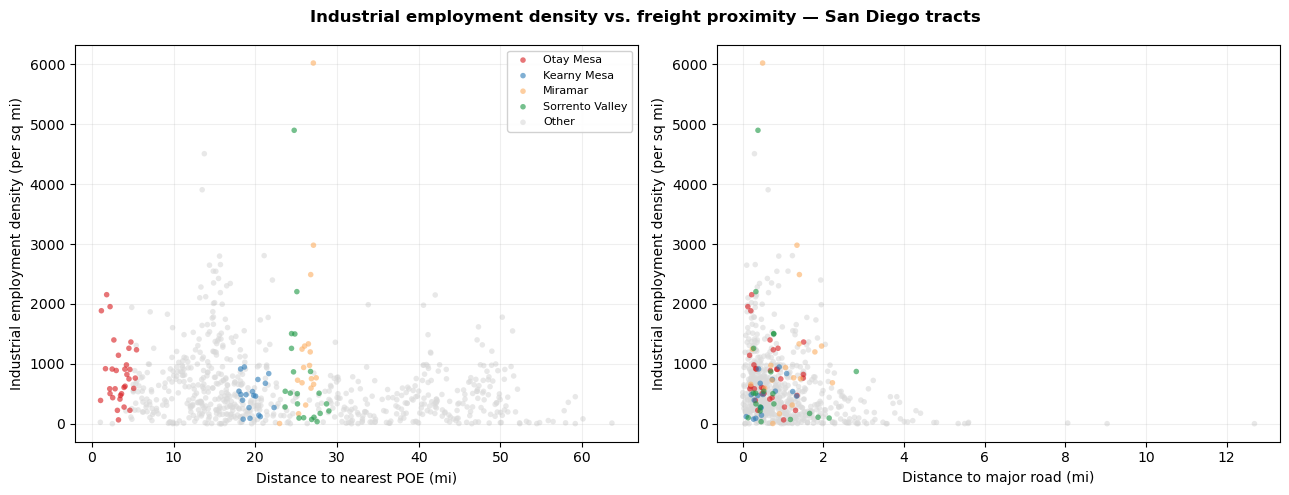

In [35]:
colors = {"Otay Mesa":"#d7191c","Kearny Mesa":"#2c7bb6",
          "Miramar":"#fdae61","Sorrento Valley":"#1a9641","Other":"#d9d9d9"}
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, xcol, xlab in [(axes[0], "dist_poe_mi", "Distance to nearest POE (mi)"),
                       (axes[1], "dist_road_mi", "Distance to major road (mi)")]:
    for a, col in colors.items():
        s = tracts[tracts["area"] == a]
        ax.scatter(s[xcol], s["industrial_emp_density"], s=16, alpha=0.6, c=col,
                   label=a, zorder=(1 if a == "Other" else 3),
                   edgecolor="none")
    ax.set_xlabel(xlab); ax.set_ylabel("Industrial employment density (per sq mi)")
    ax.grid(alpha=0.2)
axes[0].legend(fontsize=8, framealpha=0.9)
fig.suptitle("Industrial employment density vs. freight proximity — San Diego tracts",
             fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURES / "scatter_density_vs_proximity.png", dpi=200, bbox_inches="tight")
plt.show()

## 13. Map set

1. Otay Mesa context — tracts, POEs, major roads.
2. Industrial employment density (Otay Mesa).
3. Distance to nearest POE (full county, with study-area windows).

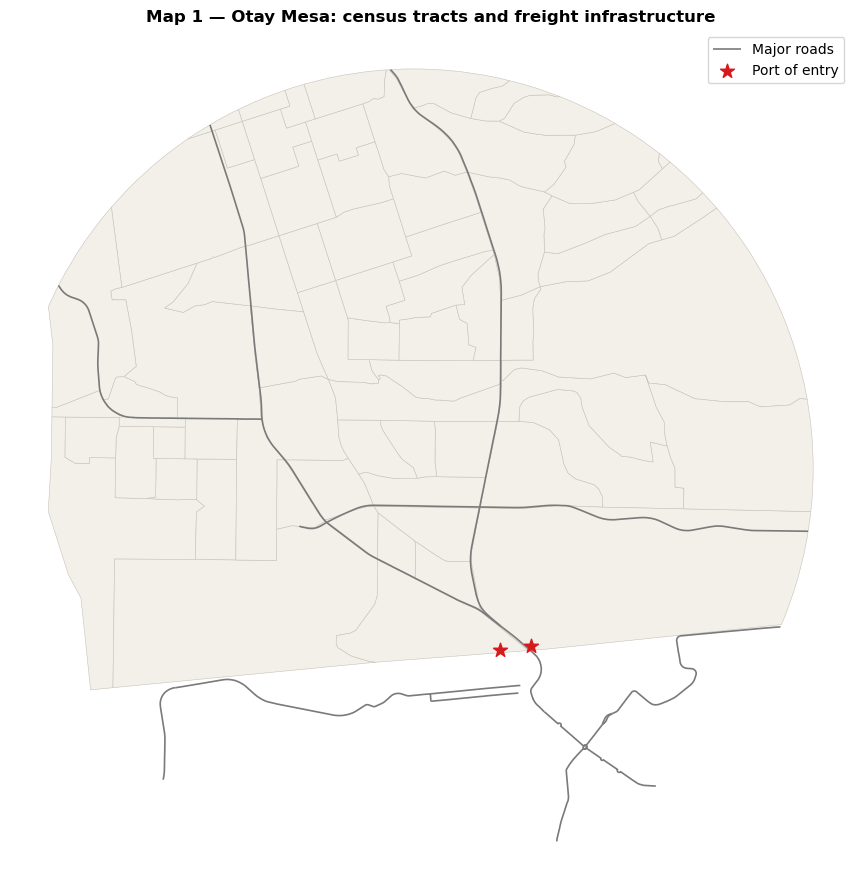

In [36]:
# Map 1 — Otay Mesa context
otay_ctx = gpd.GeoDataFrame(
    geometry=[area_windows["Otay Mesa"].buffer(2 * FT_PER_MILE)], crs=TARGET_CRS)
tr_otay = gpd.clip(tracts, otay_ctx)

fig, ax = plt.subplots(figsize=(10, 9))
tr_otay.plot(ax=ax, color="#f3f0ea", edgecolor="#c9c2b8", linewidth=0.4, zorder=1)
if roads is not None and len(roads):
    gpd.clip(roads, otay_ctx).plot(ax=ax, color="#7a7a7a", linewidth=1.2, zorder=3,
                                   label="Major roads")
gpd.clip(poe, otay_ctx).plot(ax=ax, color="#d7191c", marker="*", markersize=110,
                             zorder=5, label="Port of entry")
ax.set_title("Map 1 — Otay Mesa: census tracts and freight infrastructure",
             fontweight="bold")
ax.legend(loc="upper right"); ax.axis("off")
plt.tight_layout(); plt.savefig(FIGURES / "map1_otay_infrastructure.png", dpi=200,
                                bbox_inches="tight")
plt.show()

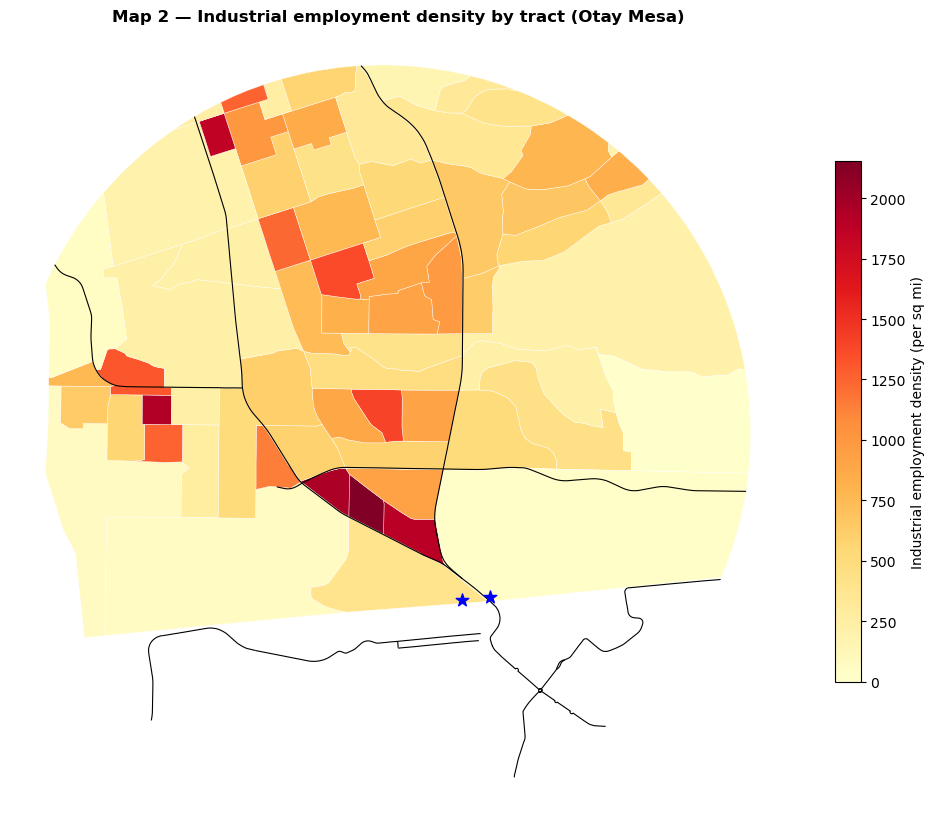

In [37]:
# Map 2 — Industrial employment density (Otay Mesa)
fig, ax = plt.subplots(figsize=(10, 9))
tr_otay.plot(ax=ax, column="industrial_emp_density", cmap="YlOrRd", legend=True,
             edgecolor="white", linewidth=0.3,
             legend_kwds={"label": "Industrial employment density (per sq mi)",
                          "shrink": 0.6},
             missing_kwds={"color": "lightgray", "label": "No data"})
if roads is not None and len(roads):
    gpd.clip(roads, otay_ctx).plot(ax=ax, color="black", linewidth=0.8, zorder=3)
gpd.clip(poe, otay_ctx).plot(ax=ax, color="blue", marker="*", markersize=90, zorder=5)
ax.set_title("Map 2 — Industrial employment density by tract (Otay Mesa)",
             fontweight="bold")
ax.axis("off")
plt.tight_layout(); plt.savefig(FIGURES / "map2_industrial_density.png", dpi=200,
                                bbox_inches="tight")
plt.show()

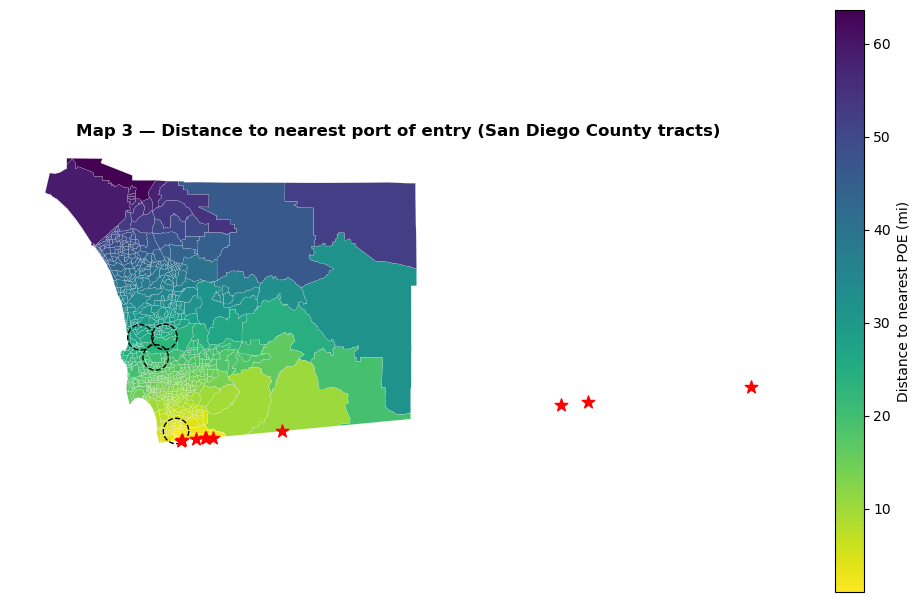

In [38]:
# Map 3 — Distance to nearest POE (full county)
fig, ax = plt.subplots(figsize=(10, 10))
tracts.plot(ax=ax, column="dist_poe_mi", cmap="viridis_r", legend=True,
            edgecolor="white", linewidth=0.1,
            legend_kwds={"label": "Distance to nearest POE (mi)", "shrink": 0.6})
poe.plot(ax=ax, color="red", marker="*", markersize=90, zorder=5)
for name, win in area_windows.items():
    gpd.GeoSeries([win], crs=TARGET_CRS).boundary.plot(
        ax=ax, color="black", linewidth=1.0, linestyle="--", zorder=4)
ax.set_title("Map 3 — Distance to nearest port of entry (San Diego County tracts)",
             fontweight="bold")
ax.axis("off")
plt.tight_layout(); plt.savefig(FIGURES / "map3_distance_to_poe.png", dpi=200,
                                bbox_inches="tight")
plt.show()

## 14. Optional cross-check — "industrially relevant land" (zoning + General Plan)

A *secondary* check only; the analysis above does not depend on it. The instructor noted that
zoning designations may reflect **leftover land** rather than deliberate freight access — which
is exactly why census-tract employment is the primary unit. This cell is wrapped in
`try/except`, so a failed City download does not stop the notebook.

[ok] City of San Diego zoning: 3,706 features
Industrial-zoned polygons: 196


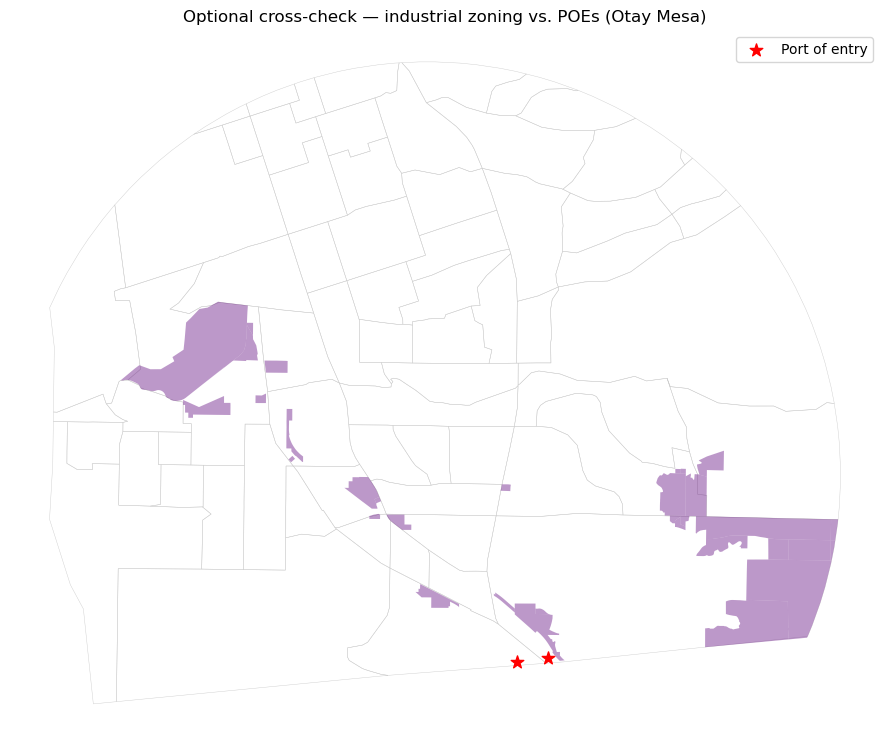

In [39]:
CITY_URLS = {
    "zoning": "https://geo.sandag.org/server/rest/directories/downloads/Zoning_Base_SD.geojson",
}
IND_ZONE_PREFIXES = ("IP", "IL", "IH", "IS", "IBT")  # Industrial Park/Light/Heavy/Small/Bus-Tech
try:
    zoning = read_geojson_url(CITY_URLS["zoning"], "City of San Diego zoning")
    zcol = next((c for c in zoning.columns if "zone" in c.lower()), None)
    if zcol:
        ind_zone = zoning[zoning[zcol].astype(str).str.upper()
                          .str.startswith(IND_ZONE_PREFIXES)].copy()
    else:
        ind_zone = zoning.iloc[0:0]
    print("Industrial-zoned polygons:", len(ind_zone))

    fig, ax = plt.subplots(figsize=(9, 9))
    gpd.clip(tracts, otay_ctx).boundary.plot(ax=ax, color="#cccccc", linewidth=0.3, zorder=1)
    if len(ind_zone):
        gpd.clip(ind_zone, otay_ctx).plot(ax=ax, color="#7b3294", alpha=0.5, zorder=2,
                                          label="Industrial zoning")
    gpd.clip(poe, otay_ctx).plot(ax=ax, color="red", marker="*", markersize=90, zorder=5,
                                 label="Port of entry")
    ax.set_title("Optional cross-check — industrial zoning vs. POEs (Otay Mesa)")
    ax.legend(); ax.axis("off")
    plt.tight_layout(); plt.savefig(FIGURES / "optional_industrial_zoning.png", dpi=200,
                                    bbox_inches="tight")
    plt.show()
except Exception as e:
    print("[optional] City zoning not loaded — skipping cross-check:", e)
    print("This does not affect the census-tract analysis above.")

## 15. Interpretation and limitations

**Reading the results.** A negative `density ~ dist_poe_mi` slope/correlation and lower mean
`dist_poe_mi` for Otay Mesa than for the non-border comparison areas would indicate that
industrial activity in the border zone is **spatially associated** with port access. The
corridor area-share and `dist_road_mi` measures say the same thing for freight roads.

**Use association language, not causal claims.**
> *"Industrial activity in Otay Mesa shows a structured spatial association with border-serving
> freight infrastructure, stronger than in comparable non-border industrial areas."*

Avoid: *"freight infrastructure caused industrial development."*

**Limitations.**
- *Leftover-land confounding (instructor's point).* San Diego's industrial land is partly what
  was left after residential/commercial/open-space allocation, so proximity may be incidental.
- *ACS measures workers, not facilities.* Employment is summarized by tract; it does not pinpoint
  plants, and `DP03_0038E` bundles utilities with transportation/warehousing (use detail table
  `C24030` to separate them).
- *Straight-line distance* is a simplification; network/drive-time distance would be stronger.
- *Study windows are researcher-defined* circles; results can shift with radius and center.
- *Edge effect.* The data describe only the U.S. side of an international boundary.
- *Comparisons are descriptive*; the OLS here is exploratory, not a causal model.